<a href="https://colab.research.google.com/github/jumafernandez/ANN-UNSL/blob/main/notebooks/notebook_03_estados_latentes_dinamicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧩 Notebook 03 — Estados Latentes Dinámicos para Diálogos (Dynamic Conversational Latent States)

En esta notebook extendemos los experimentos de recuperación semántica incorporando **embeddings dinámicos**, un mecanismo que modela la evolución del estado latente de cada conversación.

Hasta ahora utilizamos únicamente **embeddings estáticos**, es decir, un vector por turno **sin incorporar contexto previo**.  
Sin embargo, los diálogos son procesos *temporales*, y cada turno depende de lo que ocurrió antes.

Por eso introducimos:

## 🔄 Dynamic Conversational Latent States  
Una representación que actualiza un estado interno por cada diálogo en función del embedding actual y del estado previo.

Esta formulación permite estudiar:

- cómo evoluciona semánticamente una conversación,
- cómo afecta el contexto acumulado a la recuperación por ANN,
- qué técnicas de actualización preservan mejor el significado,
- y cómo comparar embeddings estáticos vs dinámicos bajo FAISS.

In [ ]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 29.7 MB/s eta 0:00:00


## 🧩 1. Recuperación de información

En esta sección recuperamos:

- los IDs de los embeddings estáticos
- los embeddings estáticos (baseline)
- el dataset procesado en la Notebook 01  
- para luego generar y comparar los embeddings dinámicos

Estos elementos son esenciales porque:
- los embeddings estáticos son el *baseline* del sistema
- permiten calcular el *recall@k* contra métodos ANN
- permiten comparar semánticamente *estático vs dinámico*


In [ ]:
import gdown
import numpy as np

Para facilitar los experimentos, se cargaron los embeddings generados mediante `all-mpnet-base-v2` y `all-MiniLM-L6-v2` en un repositorio de Google Drive y se permite parametrizar la notebook de acuerdo a la ejecución que se desea realizar:

In [ ]:
# EMBEDDING_EXPERIMENTO = 'all-mpnet-base-v2'
EMBEDDING_EXPERIMENTO = 'all-MiniLM-L6-v2'

# Embeddings `all-mpnet-base-v2`
id_embeddings = "13OWNpaWYT0nQKUtnb4LeLWvQEgCOEIkL"

if EMBEDDING_EXPERIMENTO == 'all-MiniLM-L6-v2':
  # Embeddings `all-MiniLM-L6-v2`
  id_embeddings = "1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA"

# Ids de los embeddings
id_ids = "1Pa9MU4MFJZEJWiaff7xaCBeGSR8UGFYD"

# Dataset para generar la replicabilidad
id_dataset = "118WIMyxlJ3VksRY0q9cal8Z_76BzwoDy"

In [ ]:
# Descarga de archivos
gdown.download(f"https://drive.google.com/uc?id={id_ids}", "ids.npy", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={id_embeddings}", "embeddings.npy", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={id_dataset}", "multiwoz_turns.pkl", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Pa9MU4MFJZEJWiaff7xaCBeGSR8UGFYD
To: /content/ids.npy
100%|██████████| 1.14M/1.14M [00:00<00:00, 20.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA
From (redirected): https://drive.google.com/uc?id=1x0zT0yxQ93MN1B31BLVo8vIkOT5XbFaA&confirm=t&uuid=3618e785-e524-41f6-bb6e-0611cd36eb4a
To: /content/embeddings.npy
100%|██████████| 220M/220M [00:03<00:00, 69.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=118WIMyxlJ3VksRY0q9cal8Z_76BzwoDy
To: /content/multiwoz_turns.pkl
100%|██████████| 14.2M/14.2M [00:00<00:00, 37.0MB/s]


'multiwoz_turns.pkl'

In [ ]:
# Carga de arrays
ids = np.load("ids.npy")
embeddings = np.load("embeddings.npy")

In [ ]:
ids.shape, embeddings.shape

((143044,), (143044, 384))

In [ ]:
import pandas as pd

# Cargar el dataset unificado generado en la Notebook 01
df = pd.read_pickle("multiwoz_turns.pkl")

df.shape

(143044, 5)

In [ ]:
df = df.sort_values(by=["dialogue_id", "turn_id"]).reset_index(drop=True)

### Definición y embedding del query

Luego cargamos el modelo y realizamos el embedding de la consulta que vamos a ejecutar sobre las diferentes estrategias de búsqueda:

In [ ]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo deseado para realizar el embedding de la consulta
model_name = f"sentence-transformers/{EMBEDDING_EXPERIMENTO}"
model = SentenceTransformer(model_name)

print("Modelo cargado:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado: sentence-transformers/all-MiniLM-L6-v2


Definimos el query a utilizar para la búsqueda de embeddings:

In [ ]:
query = "I need to book a restaurant tonight for two people."

Generamos el embedding del query:

In [ ]:
# Generar embedding de la consulta (usar mismo modelo)
query_emb = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

In [ ]:
query_emb

array([[ 3.25249508e-02, -4.36187945e-02, -1.00657651e-02,
         5.10801226e-02, -1.94223031e-01,  4.89991233e-02,
        -4.29800972e-02, -6.50784746e-02, -1.78417861e-02,
        -6.53045326e-02,  4.70071808e-02,  3.31197605e-02,
        -3.15227620e-02, -1.99578628e-02,  1.11053409e-02,
        -1.05088785e-01,  8.43624398e-02,  5.36431409e-02,
         8.18504840e-02, -2.11447421e-02,  8.81869905e-03,
        -1.75343044e-02, -5.52746430e-02, -2.69612502e-02,
        -2.63591986e-02, -3.65736857e-02, -1.94982551e-02,
        -9.52184107e-03, -3.36714648e-02, -2.42722295e-02,
        -3.50072794e-02, -4.17644270e-02,  2.59794686e-02,
         1.80619378e-02, -2.61083320e-02, -2.33505722e-02,
         1.00042522e-01, -3.37737910e-02,  7.74090961e-02,
         1.68105718e-02, -8.57948326e-03, -8.04116111e-03,
        -3.45291980e-02, -8.95300414e-03,  1.48010822e-02,
         5.25919115e-03, -1.02512866e-01,  2.46792454e-02,
         7.97572955e-02,  9.05143544e-02, -4.02513593e-0

## 🔥 ¿Por qué embeddings dinámicos?

En un diálogo, cada turno **no es independiente**: las intenciones, la semántica y el tópico cambian progresivamente.

Los embeddings estáticos representan cada turno por separado, pero no capturan:

- el tema acumulado,
- el contexto compartido,
- la coherencia interna,
- las dependencias temporales entre turnos.

Para superar estas limitaciones, definimos un **estado latente dinámico** $h_t$ que resume todo lo ocurrido hasta el turno $t$ dentro de una conversación.

La forma general de un estado dinámico es:

$$
h_0 = f(e_0)
$$

$$
h_t = F(h_{t-1}, e_t)
$$

donde:

- $e_t$ es el embedding estático del turno actual  
- $h_{t-1}$ es el estado previo del diálogo  
- $F(\cdot)$ es una regla de actualización dinámica  
- $h_t$ es el embedding dinámico acumulado  


## 🔧 Funciones de actualización dinámica

Implementamos varias variantes para $F(h_{t-1}, e_t)$:



**1. Mean Accumulator (baseline simple)**:

$h_t = \frac{h_{t-1} + e_t}{2}$

**2. Alpha-Mixture**

$h_t = \alpha h_{t-1} + (1-\alpha) e_t$

**3. Add + LayerNorm (recomendada)**

$h_t = \text{LayerNorm}(h_{t-1} + e_t)$

Esta variante:
- preserva magnitudes,
- mantiene estabilidad numérica,
- y representa mejor la semántica combinada.


**4. GRU-lite (inspirada en RNNs sin gates)**

$h_t = \tanh(W_h h_{t-1} + W_x e_t)$

**5. Static Embedding (baseline)**

$h_t = e_t$


Estas funciones permiten comparar qué tan bien cada representación dinámica impacta la recuperación aproximada (ANN).

In [ ]:
import numpy as np
import torch
import torch.nn as nn


def update_add_norm(h_prev, emb, ln):
    """h_t = LayerNorm(h_prev + emb)"""
    h = h_prev + emb
    return ln(h)

def update_mean(h_prev, emb):
    """h_t = promedio incremental"""
    return 0.5 * (h_prev + emb)

def update_alpha(h_prev, emb, alpha=0.7):
    """h_t = α·h_prev + (1−α)·emb"""
    return alpha * h_prev + (1 - alpha) * emb

def update_gru_lite(h_prev, emb, W_h, W_x):
    """
    Variante simple inspirada en GRU sin gates:
    h_t = tanh(W_h·h_prev + W_x·emb)
    """
    return torch.tanh(W_h(h_prev) + W_x(emb))

def update_static(h_prev, emb):
    """No actualiza nada, solo usa el embedding actual (baseline)."""
    return emb

## 🏗️ Generación de estados dinámicos

La función principal recorre el dataset ordenado por conversación y turno.  
Para cada turno:

1. Detecta si comienza una nueva conversación  
2. Calcula el estado dinámico según la variante elegida  
3. Guarda el estado $h_t$
4. Devuelve una matriz final del mismo tamaño que los embeddings estáticos  

Esto permite usar FAISS directamente sobre embeddings dinámicos y comparar rendimiento, recall y estabilidad semántica.


In [ ]:
def compute_dynamic_states(df, embeddings, mode="add_norm", alpha=0.7):
    """
    Genera estados latentes dinámicos conversación a conversación.

    df: DataFrame con columnas (dialogue_id, turn_id)
    embeddings: numpy array de tamaño (N, 768)
    mode: "add_norm", "mean", "alpha", "gru_lite", "static"
    alpha: parámetro para la variante alpha
    """

    # Ordenamos para asegurar consistencia
    df_sorted = df.sort_values(["dialogue_id", "turn_id"]).reset_index(drop=True)

    # Preparamos el contenedor final
    dynamic_states = np.zeros_like(embeddings, dtype=np.float32)

    # Inicializamos módulos especiales si son necesarios
    ln = nn.LayerNorm(embeddings.shape[1]) if mode == "add_norm" else None

    if mode == "gru_lite":
        hidden_size = embeddings.shape[1]
        W_h = nn.Linear(hidden_size, hidden_size, bias=False)
        W_x = nn.Linear(hidden_size, hidden_size, bias=False)

    current_dialogue = None
    h_prev = None

    # Recorremos cada turno
    for idx, row in df_sorted.iterrows():
        emb = torch.tensor(embeddings[idx], dtype=torch.float32)

        # Si comenzó una nueva conversación → reiniciamos el estado
        if row["dialogue_id"] != current_dialogue:
            h_prev = emb  # estado inicial = embedding del primer turno
            current_dialogue = row["dialogue_id"]
            dynamic_states[idx] = h_prev.numpy()
            continue

        # Seleccionamos la variante de actualización
        if mode == "add_norm":
            h_prev = update_add_norm(h_prev, emb, ln)

        elif mode == "mean":
            h_prev = update_mean(h_prev, emb)

        elif mode == "alpha":
            h_prev = update_alpha(h_prev, emb, alpha=alpha)

        elif mode == "gru_lite":
            h_prev = update_gru_lite(h_prev, emb, W_h, W_x)

        elif mode == "static":
            h_prev = update_static(h_prev, emb)

        else:
            raise ValueError(f"Modo desconocido: {mode}")

        dynamic_states[idx] = h_prev.detach().numpy()

    return dynamic_states

In [ ]:
dynamic_embeddings = compute_dynamic_states(df, embeddings, mode="add_norm")

In [ ]:
dynamic_embeddings.shape

(143044, 384)

## 4. Inspección de Embeddings Dinámicos

Aquí comprobamos:

- La dimensión resultante (debería ser igual a la estática: 768)
- Algunos ejemplos de estados dinámicos dentro de una conversación
- La variación progresiva entre turnos (esperable si la técnica funciona)

También verificamos que la estructura respete el orden del diálogo.


In [ ]:
groups = df.sort_values(["dialogue_id", "turn_id"]).groupby("dialogue_id")

In [ ]:
import numpy as np

def compute_similarity_series(df, embeddings, dynamic_embeddings):
    series = {}

    for dlg_id, dlg in groups:
        idx = dlg.index.to_numpy()              # índices globales
        static = embeddings[idx]
        dynamic = dynamic_embeddings[idx]

        sim = np.sum(static * dynamic, axis=1) / (
            np.linalg.norm(static, axis=1) * np.linalg.norm(dynamic, axis=1)
        )

        series[dlg_id] = {
            "turn_ids": dlg["turn_id"].tolist(),
            "sim": sim
        }

    return series

In [ ]:
similarity_series = compute_similarity_series(df, embeddings, dynamic_embeddings)

In [ ]:
similarity_series['MUL0001.json']

{'turn_ids': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19],
 'sim': array([1.0000001 , 0.8673087 , 0.24855809, 0.23222749, 0.10172014,
        0.1725149 , 0.6438871 , 0.5933177 , 0.43898815, 0.32078087,
        0.1405634 , 0.7118922 , 0.3643307 , 0.47098967, 0.46148452,
        0.7270463 , 0.67104244, 0.33109593, 0.20616391, 0.2707112 ],
       dtype=float32)}

## Evolución de la similitud entre embeddings de turno y estados dinámicos

Para analizar el efecto de los estados latentes dinámicos se calculó, dentro de cada diálogo, la similitud coseno entre el embedding estático del turno y el estado dinámico correspondiente.

Mientras que el embedding estático representa únicamente el contenido semántico del turno actual, el estado dinámico incorpora información acumulada del historial conversacional. La evolución de esta similitud permite observar cómo la representación dinámica se aleja progresivamente de la representación local a medida que el diálogo avanza.

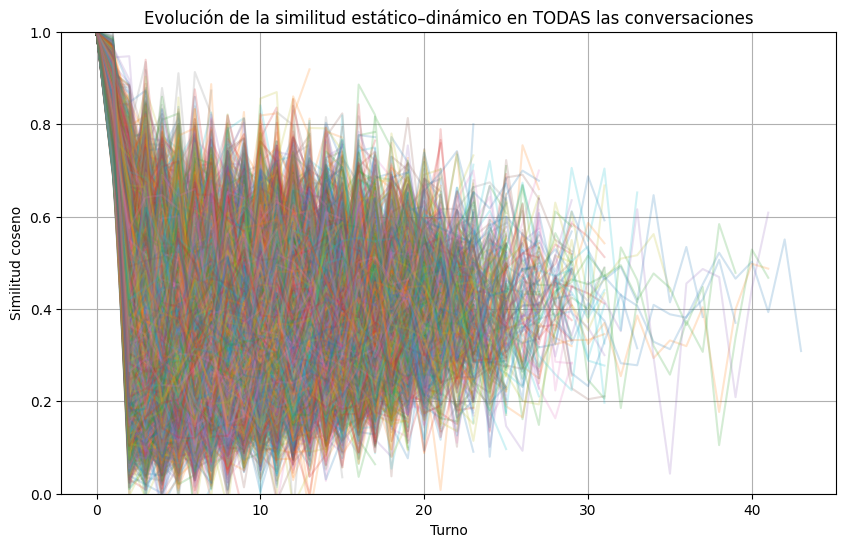

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for dlg_id, data in similarity_series.items():
    plt.plot(data["turn_ids"], data["sim"], alpha=0.2)

plt.ylim(0,1)
plt.title("Evolución de la similitud estático–dinámico en TODAS las conversaciones")
plt.xlabel("Turno")
plt.ylabel("Similitud coseno")
plt.grid(True)
plt.show()

## Análisis agregado de la evolución de la similitud

Dado que la visualización de todas las conversaciones produce una figura altamente densa, se calcula una medida de tendencia central de la similitud coseno entre los embeddings de turno y los estados dinámicos.

Para cada posición de turno dentro del diálogo se agregan las similitudes correspondientes a todas las conversaciones del corpus. A partir de estos valores se calcula tanto la **media** como la **mediana**, lo que permite observar la tendencia general de divergencia entre las representaciones estáticas y dinámicas a lo largo del diálogo.

Esta representación agregada permite identificar patrones globales que no son fácilmente visibles cuando se grafican simultáneamente todas las conversaciones.

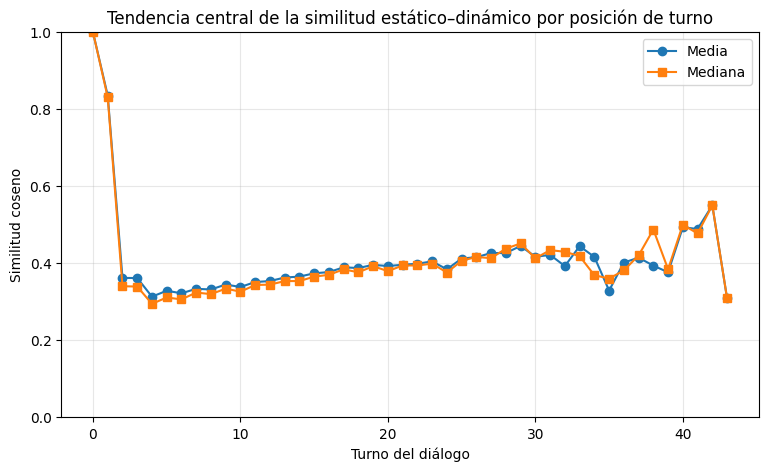

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Agrupar similitudes por posición de turno
bucket = defaultdict(list)

for dlg_id, data in similarity_series.items():
    for t, s in zip(data["turn_ids"], data["sim"]):
        bucket[t].append(float(s))

turns = sorted(bucket.keys())
mean_sim = [np.mean(bucket[t]) for t in turns]
median_sim = [np.median(bucket[t]) for t in turns]

plt.figure(figsize=(9,5))
plt.plot(turns, mean_sim, marker="o", label="Media")
plt.plot(turns, median_sim, marker="s", label="Mediana")

plt.ylim(0, 1)
plt.xlabel("Turno del diálogo")
plt.ylabel("Similitud coseno")
plt.title("Tendencia central de la similitud estático–dinámico por posición de turno")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Análisis cualitativo en un subconjunto de conversaciones

Además del análisis agregado, se selecciona un subconjunto de conversaciones del corpus para observar con mayor detalle la evolución de la similitud dentro de diálogos individuales.

Para este análisis se eligen conversaciones relativamente largas, lo que permite visualizar cómo varía la relación entre el embedding del turno y el estado dinámico acumulado a lo largo de la interacción. Esta visualización facilita la inspección cualitativa de la variabilidad entre diálogos y complementa el análisis estadístico agregado presentado anteriormente.

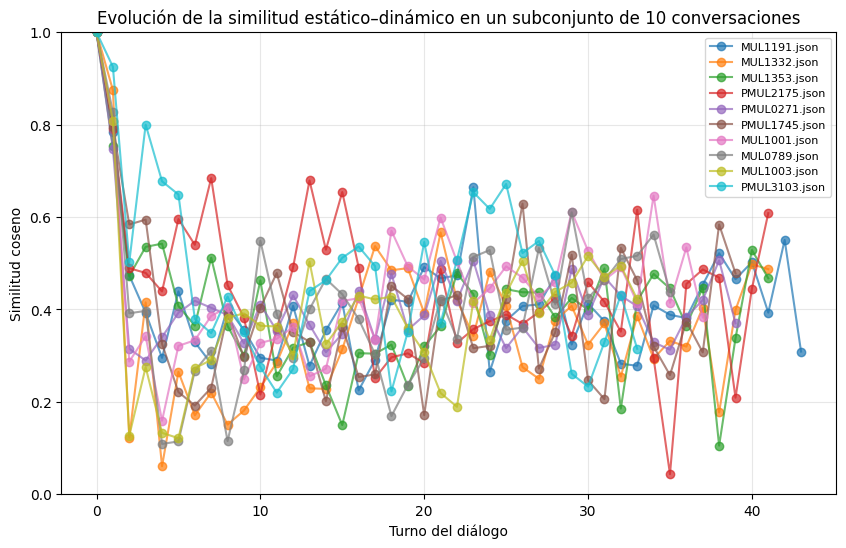

In [ ]:
import matplotlib.pyplot as plt

# Cantidad de conversaciones a mostrar
n_dialogos = 10

# Elegir las conversaciones más largas
dialogos_ordenados = sorted(
    similarity_series.keys(),
    key=lambda k: len(similarity_series[k]["turn_ids"]),
    reverse=True
)

dialogos_seleccionados = dialogos_ordenados[:n_dialogos]

plt.figure(figsize=(10,6))

for dlg_id in dialogos_seleccionados:
    data = similarity_series[dlg_id]
    plt.plot(data["turn_ids"], data["sim"], marker="o", alpha=0.7, label=dlg_id)

plt.ylim(0, 1)
plt.xlabel("Turno del diálogo")
plt.ylabel("Similitud coseno")
plt.title(f"Evolución de la similitud estático–dinámico en un subconjunto de {n_dialogos} conversaciones")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, loc="best")
plt.show()

## ✅ Comparación de vecinos recuperados: embeddings estáticos vs estados dinámicos

Para analizar el impacto de los estados latentes dinámicos en la recuperación vectorial, se comparan los vecinos más cercanos obtenidos utilizando dos tipos de representaciones:

- embeddings estáticos de turno
- estados dinámicos que incorporan el contexto acumulado del diálogo

Para cada consulta se recuperan los *k* vecinos más cercanos utilizando ambos tipos de representación. Posteriormente se calcula la intersección entre los conjuntos de vecinos obtenidos, lo que permite medir cuánto cambia el ranking de recuperación al utilizar estados dinámicos.

Este análisis permite evaluar si la incorporación del contexto conversacional modifica de manera significativa la estructura de vecinos en el espacio vectorial.

In [ ]:
k = 5

_, idx_static = index_static.search(embeddings, k)
_, idx_dynamic = index_dynamic.search(dynamic_embeddings, k)

overlaps = []

for i in range(len(idx_static)):
    set_static = set(idx_static[i])
    set_dynamic = set(idx_dynamic[i])

    overlap = len(set_static.intersection(set_dynamic)) / k
    overlaps.append(overlap)

print("Overlap promedio:", np.mean(overlaps))

Overlap promedio: 0.20121780710830237


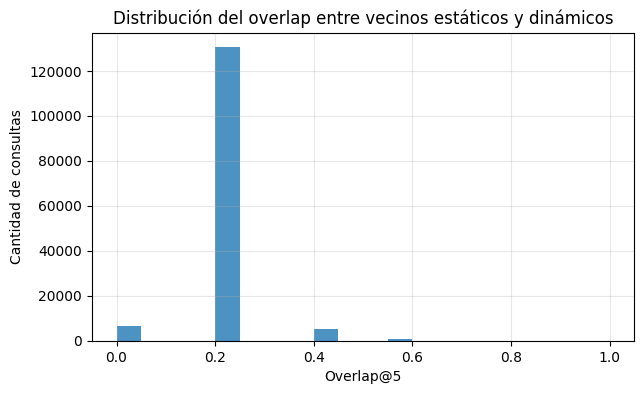

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.hist(overlaps, bins=20, alpha=0.8)

plt.xlabel("Overlap@5")
plt.ylabel("Cantidad de consultas")
plt.title("Distribución del overlap entre vecinos estáticos y dinámicos")

plt.grid(alpha=0.3)

plt.show()

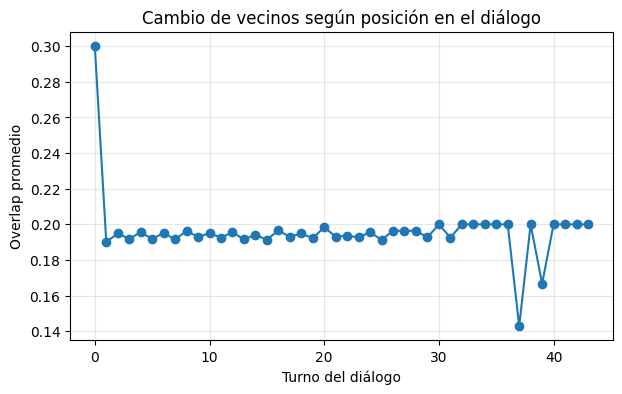

In [ ]:
from collections import defaultdict
import numpy as np

bucket = defaultdict(list)

for i in range(len(overlaps)):
    turn = df.loc[i, "turn_id"]
    bucket[turn].append(overlaps[i])

turns = sorted(bucket.keys())
mean_overlap = [np.mean(bucket[t]) for t in turns]

plt.figure(figsize=(7,4))

plt.plot(turns, mean_overlap, marker="o")

plt.xlabel("Turno del diálogo")
plt.ylabel("Overlap promedio")
plt.title("Cambio de vecinos según posición en el diálogo")

plt.grid(alpha=0.3)

plt.show()

## 📈 Visualización del espacio semántico mediante reducción de dimensionalidad

Finalmente, se explora la estructura del espacio vectorial generado por las representaciones semánticas mediante técnicas de reducción de dimensionalidad. En particular, se utiliza UMAP para proyectar los embeddings de alta dimensionalidad en un espacio bidimensional.

Este tipo de visualización permite observar de manera cualitativa cómo se distribuyen las representaciones en el espacio semántico y si los estados dinámicos producen una organización distinta respecto de los embeddings estáticos de turno.

Dado el tamaño del corpus, la visualización se realiza sobre un subconjunto de los vectores para facilitar la interpretación gráfica.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


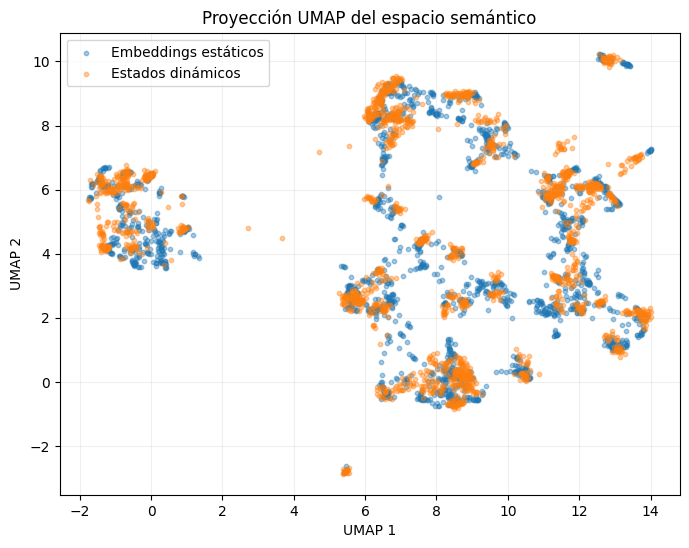

In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# tamaño del subconjunto para visualizar
n = 2000

static_sample = embeddings[:n]
dynamic_sample = dynamic_embeddings[:n]

reducer = umap.UMAP(random_state=42)

proj_static = reducer.fit_transform(static_sample)
proj_dynamic = reducer.transform(dynamic_sample)

plt.figure(figsize=(8,6))

plt.scatter(
    proj_static[:,0],
    proj_static[:,1],
    alpha=0.4,
    s=10,
    label="Embeddings estáticos"
)

plt.scatter(
    proj_dynamic[:,0],
    proj_dynamic[:,1],
    alpha=0.4,
    s=10,
    label="Estados dinámicos"
)

plt.title("Proyección UMAP del espacio semántico")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()